<a href="https://colab.research.google.com/github/Kryptera-K/CHRW-Bearish-Momentum-Absorption-Strategy/blob/main/CHRW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "CHRW"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("CHRW_clean.csv", index=False)
df

/tmp/ipython-input-912394782.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,6.018182,6.152774,5.979727,6.152774,1029600
2000-01-04,5.816297,5.922047,5.816297,5.922047,805600
2000-01-05,5.739385,5.806681,5.700930,5.768226,809600
2000-01-06,5.768228,5.768228,5.691318,5.691318,1070800
2000-01-07,5.845137,5.845137,5.720158,5.777841,554800
...,...,...,...,...,...
2025-12-24,164.949997,166.059998,164.690002,165.279999,428100
2025-12-26,164.630005,165.330002,163.800003,164.410004,453800
2025-12-29,163.940002,165.089996,163.089996,164.490005,872100


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

MACD_FAST = 12
MACD_SIGNAL = 9
MACD_SLOW = 26
QQE_FACTOR = 4.236
QQE_LEVEL = 50
QQE_PERIOD = 14
QQE_SMOOTH = 5

# -------------------------
# Indicator Functions
# -------------------------

def macd_lower_0(df):
    df = calculate_macd(df)
    return df["MACD"] < 0


def calculate_macd(df, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    """
    Calculate MACD and Signal lines.
    """
    df = df.copy()
    df["EMA_fast"] = df["Close"].ewm(span=fast, adjust=False).mean()
    df["EMA_slow"] = df["Close"].ewm(span=slow, adjust=False).mean()
    df["MACD"] = df["EMA_fast"] - df["EMA_slow"]
    df["Signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()

    # Previous values for comparisons
    df["MACD_prev"] = df["MACD"].shift(1)
    df["Signal_prev"] = df["Signal"].shift(1)

    return df


def qqe_cross_above_level(df, level=QQE_LEVEL):
    df = calculate_qqe(df)
    return (df['QQE_Value1'] > level) & (df['QQE_Value1'].shift(1) <= level)


def calculate_qqe(df, rsi_period=QQE_PERIOD, smooth=QQE_SMOOTH, factor=QQE_FACTOR):
    """
    Calculate QQE lines (Value1 & Value2) based on RSI smoothing and ATR-like smoothing.
    """
    df = df.copy()

    # --- RSI ---
    delta = df['Close'].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/rsi_period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/rsi_period, adjust=False).mean()
    rsi = 100 - (100 / (1 + roll_up / roll_down))

    # --- Smoothed RSI ---
    rsi_ma = rsi.rolling(window=smooth).mean().fillna(method='bfill')

    # --- RSI Delta & ATR-like smoothing ---
    rsi_delta = rsi_ma.diff().abs().fillna(0)
    atr_rsi = rsi_delta.ewm(alpha=1/smooth, adjust=False).mean()

    # --- QQE Calculation ---
    value1 = rsi_ma.copy()
    value2 = pd.Series(index=df.index, dtype=float)
    value2.iloc[0] = value1.iloc[0]

    for i in range(1, len(df)):
        prev_trail = value2.iloc[i-1]
        prev_value1 = value1.iloc[i-1]
        atr = atr_rsi.iloc[i]
        direction = 1 if prev_value1 > prev_trail else -1
        value2.iloc[i] = prev_trail + direction * factor * atr

    df['QQE_Value1'] = value1
    df['QQE_Value2'] = value2

    return df



# -------------------------
# Entry conditions
# -------------------------

df["MACD_lower_0"] = macd_lower_0(df)

# -------------------------
# Exit conditions
# -------------------------

df["QQE_Value1_CrossAbove_Level"] = qqe_cross_above_level(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'MACD_lower_0',
]
exit_conditions = [
    'QQE_Value1_CrossAbove_Level',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

/tmp/ipython-input-1213818975.py:59: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rsi_ma = rsi.rolling(window=smooth).mean().fillna(method='bfill')


Start                                2000-01-03 00:00:00
End                                  2025-12-31 00:00:00
Period                                6539 days 00:00:00
Start Value                                     100000.0
End Value                                 4988405.688822
Total Return [%]                             4888.405689
Benchmark Return [%]                         2531.495941
Max Gross Exposure [%]                             100.0
Total Fees Paid                            234141.714615
Max Drawdown [%]                               33.759632
Max Drawdown Duration                  797 days 00:00:00
Total Trades                                          60
Total Closed Trades                                   60
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   73.333333
Best Trade [%]                                 44.863676
Worst Trade [%]                

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-12-31 00:00:00
Period                         6539 days 00:00:00
Start Value                              100000.0
End Value                          2631495.940549
Total Return [%]                      2531.495941
Benchmark Return [%]                  2531.495941
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        42.606354
Max Drawdown Duration           870 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                     2531495.940549
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


/tmp/ipython-input-2662292361.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


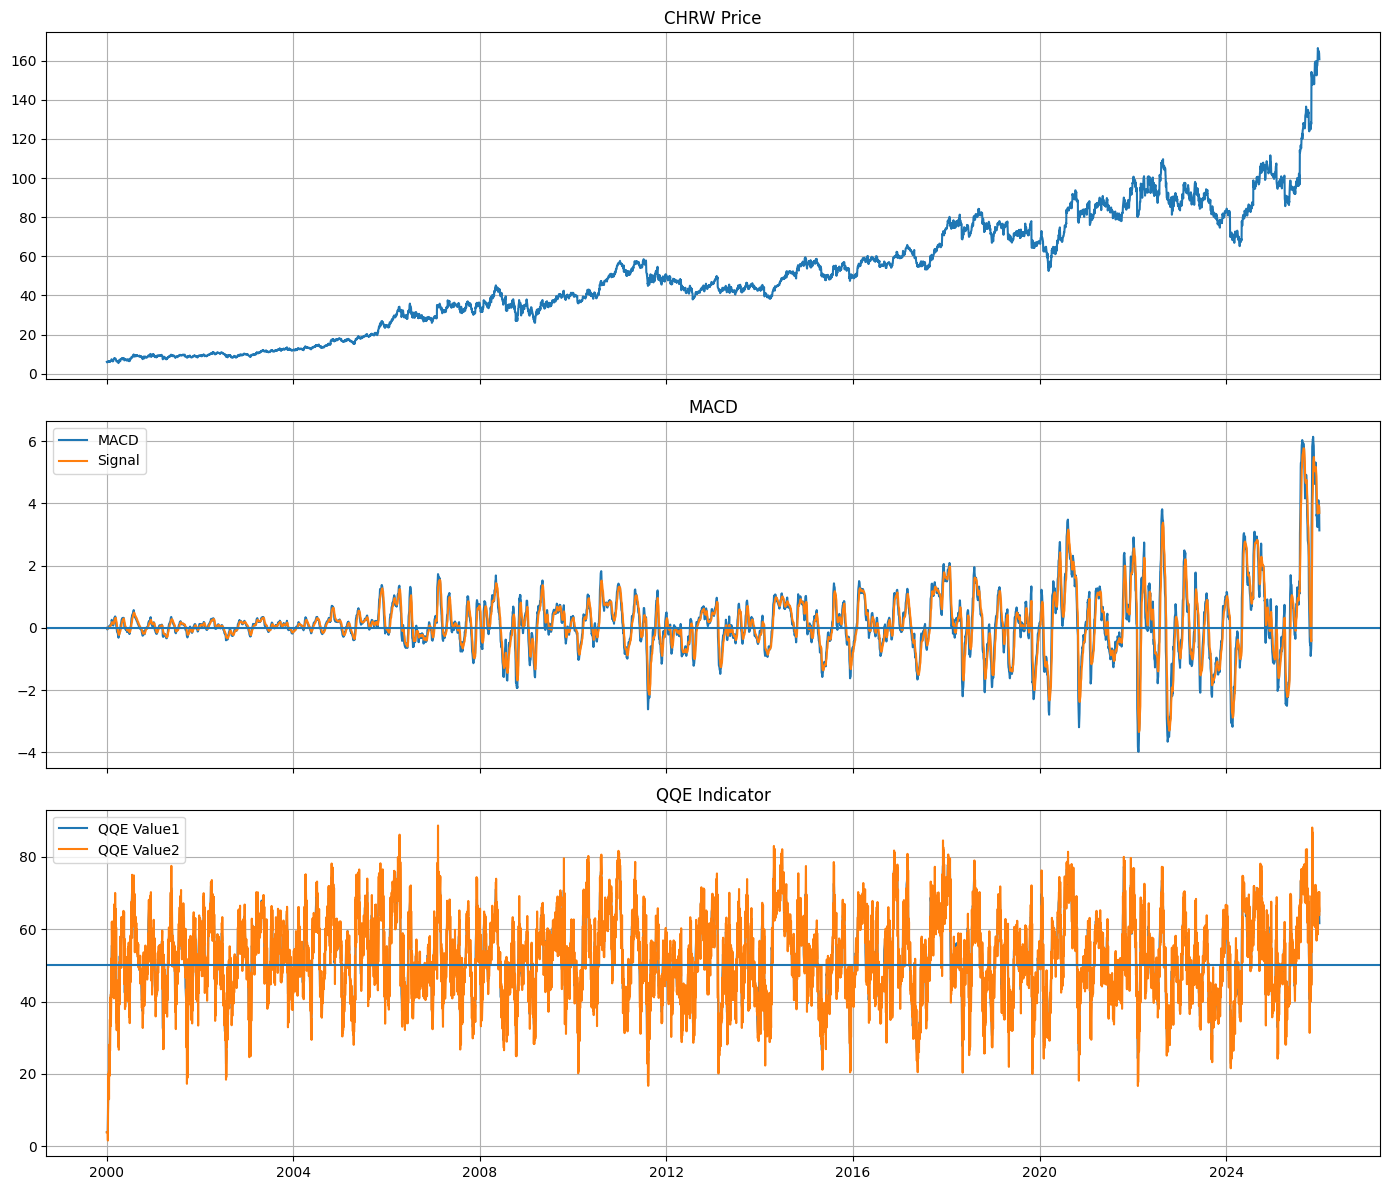

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# Download Data
# -------------------------
symbol = "CHRW"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)

# -------------------------
# Parameters
# -------------------------
MACD_FAST = 12
MACD_SIGNAL = 9
MACD_SLOW = 26
QQE_FACTOR = 4.236
QQE_LEVEL = 50
QQE_PERIOD = 14
QQE_SMOOTH = 5

# -------------------------
# Indicator Calculations
# -------------------------
def calculate_macd(df, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    df = df.copy()
    df["EMA_fast"] = df["Close"].ewm(span=fast, adjust=False).mean()
    df["EMA_slow"] = df["Close"].ewm(span=slow, adjust=False).mean()
    df["MACD"] = df["EMA_fast"] - df["EMA_slow"]
    df["Signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()
    return df

def calculate_qqe(df, rsi_period=QQE_PERIOD, smooth=QQE_SMOOTH, factor=QQE_FACTOR):
    df = df.copy()

    delta = df['Close'].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)

    roll_up = up.ewm(alpha=1/rsi_period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/rsi_period, adjust=False).mean()

    rsi = 100 - (100 / (1 + roll_up / roll_down))
    rsi_ma = rsi.rolling(window=smooth).mean().bfill()

    rsi_delta = rsi_ma.diff().abs().fillna(0)
    atr_rsi = rsi_delta.ewm(alpha=1/smooth, adjust=False).mean()

    value1 = rsi_ma.copy()
    value2 = pd.Series(index=df.index, dtype=float)
    value2.iloc[0] = value1.iloc[0]

    for i in range(1, len(df)):
        prev_trail = value2.iloc[i-1]
        prev_value1 = value1.iloc[i-1]
        atr = atr_rsi.iloc[i]
        direction = 1 if prev_value1 > prev_trail else -1
        value2.iloc[i] = prev_trail + direction * factor * atr

    df["QQE_Value1"] = value1
    df["QQE_Value2"] = value2
    return df

# -------------------------
# Apply Indicators
# -------------------------
df = calculate_macd(df)
df = calculate_qqe(df)

# -------------------------
# Plotting
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ---- Price ----
axes[0].plot(df.index, df["Close"])
axes[0].set_title("CHRW Price")
axes[0].grid(True)

# ---- MACD ----
axes[1].plot(df.index, df["MACD"], label="MACD")
axes[1].plot(df.index, df["Signal"], label="Signal")
axes[1].axhline(0)
axes[1].set_title("MACD")
axes[1].legend()
axes[1].grid(True)

# ---- QQE ----
axes[2].plot(df.index, df["QQE_Value1"], label="QQE Value1")
axes[2].plot(df.index, df["QQE_Value2"], label="QQE Value2")
axes[2].axhline(QQE_LEVEL)
axes[2].set_title("QQE Indicator")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
